<a href="https://colab.research.google.com/github/UNICODEY/rnn-lstm-sequence-prediction/blob/main/sequence_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

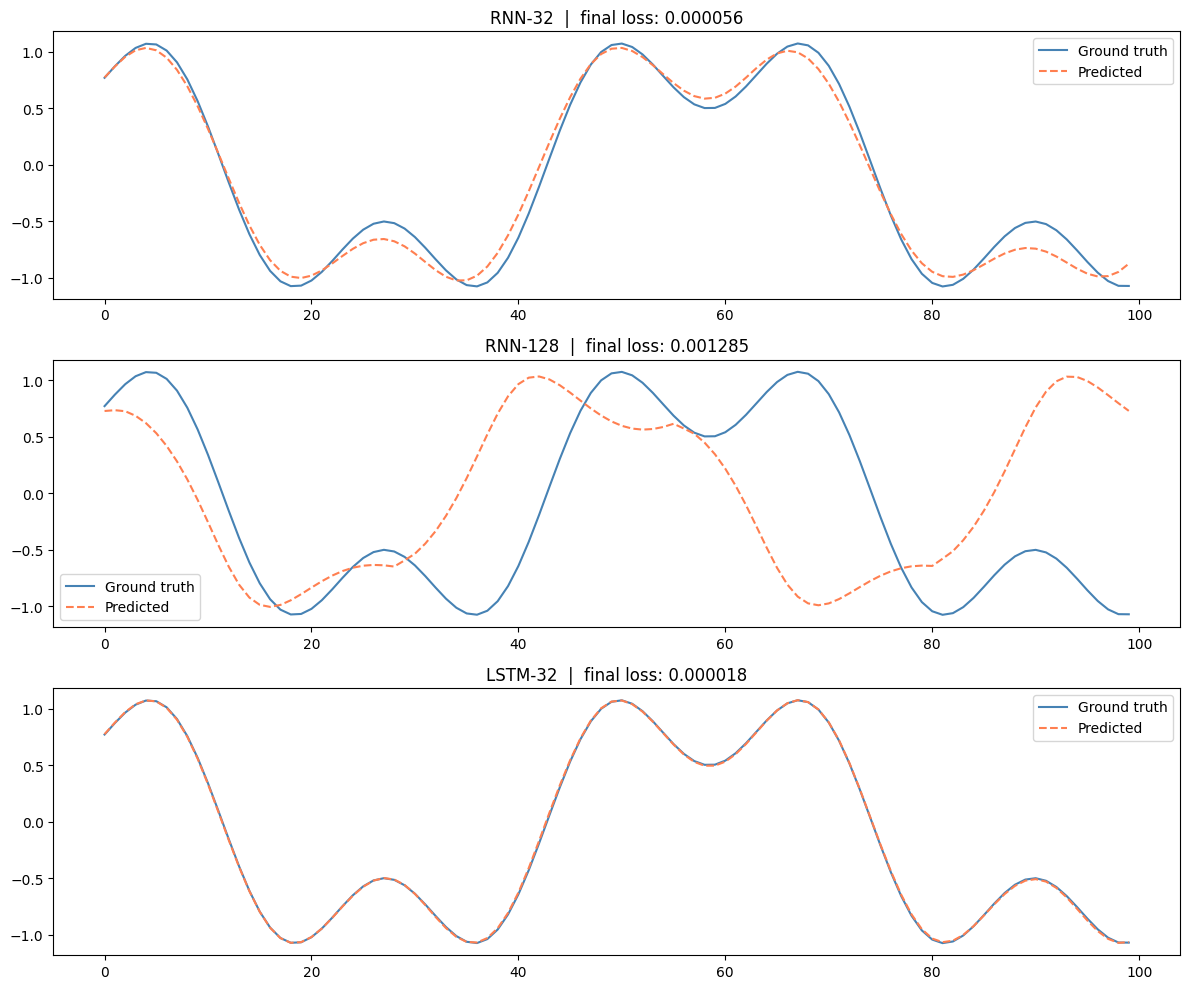

Saved: comparison.png


In [8]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# ── Data ──────────────────────────────────────────
t = np.linspace(0, 100, 1000)
data = (np.sin(t) + 0.5 * np.sin(3*t)).astype(np.float32)

def make_sequences(data, seq_len=20):
    X, Y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        Y.append(data[i+seq_len])
    return torch.tensor(X).unsqueeze(-1), torch.tensor(Y).unsqueeze(-1)

X, Y = make_sequences(data)

# ── Model ─────────────────────────────────────────
class SeqPredictor(nn.Module):
    """RNN or LSTM sequence predictor for autoregressive rollout."""
    def __init__(self, rnn_type='RNN', hidden_size=32):
        super().__init__()
        self.rnn_type = rnn_type
        if rnn_type == 'LSTM':
            self.rnn = nn.LSTM(input_size=1, hidden_size=hidden_size, batch_first=True)
        else:
            self.rnn = nn.RNN(input_size=1, hidden_size=hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :])

# ── Training ──────────────────────────────────────
def train(model, epochs=200):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    loss_fn = nn.MSELoss()
    for epoch in range(epochs):
        pred = model(X)
        loss = loss_fn(pred, Y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    return loss.item()

# ── Autoregressive rollout ────────────────────────
def rollout(model, steps=100):
    """Feed predictions back as inputs for multi-step forecasting."""
    model.eval()
    with torch.no_grad():
        current = X[0:1]
        preds = []
        for _ in range(steps):
            val = model(current)
            preds.append(val.item())
            current = torch.cat([current[:, 1:, :], val.unsqueeze(1)], dim=1)
    return preds

# ── Experiments ───────────────────────────────────
experiments = [
    ('RNN-32',  SeqPredictor('RNN',  32)),
    ('RNN-128', SeqPredictor('RNN',  128)),
    ('LSTM-32', SeqPredictor('LSTM', 32)),
]

fig, axes = plt.subplots(3, 1, figsize=(12, 10))
ground_truth = data[20:120]

for ax, (name, model) in zip(axes, experiments):
    final_loss = train(model)
    preds = rollout(model)
    ax.plot(ground_truth, label='Ground truth', color='steelblue')
    ax.plot(preds, label='Predicted', color='coral', linestyle='--')
    ax.set_title(f'{name}  |  final loss: {final_loss:.6f}')
    ax.legend()

plt.tight_layout()
plt.savefig('comparison.png', dpi=150)
plt.show()
print("Saved: comparison.png")